# Phase 6: Feature Selection\n\nIn this phase, we apply rigorous statistical and model-based techniques to select the absolute best predictive features for the `Response` variable. We aim to minimize dimensionality and remove noise before modeling.

## 1. Setup & Data Loading\nWe load the engineered dataset from Phase 5 and encode all categorical variables because statistical selection techniques require numerical inputs.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
os.makedirs('../outputs/crisp_dm_phase6/figures', exist_ok=True)
os.makedirs('../outputs/crisp_dm_phase6/tables', exist_ok=True)

df = pd.read_csv('../data/engineered_features.csv')
print(f"Engineered Dataset Shape: {df.shape}")

# One-Hot Encoding for Feature Selection
X = pd.get_dummies(df.drop('Response', axis=1), drop_first=True)
y = df['Response']
print(f"Encoded Feature Matrix Shape: {X.shape}")


Engineered Dataset Shape: (2236, 36)
Encoded Feature Matrix Shape: (2236, 41)


## 2. Variance Threshold (Zero-Variance Filter)\nFirst, we aggressively filter out features that are completely static (zero variance). A feature that never changes cannot mathematically predict the target.

In [2]:
selector = VarianceThreshold(threshold=0.0)
selector.fit(X)

zero_var_cols = X.columns[~selector.get_support()]
print(f"Features with zero variance (to be dropped): {list(zero_var_cols)}")

if len(zero_var_cols) > 0:
    X = X.drop(columns=zero_var_cols)


Features with zero variance (to be dropped): []


### Interpretation\nIf any features were flagged with zero variance, they offer absolutely no discriminatory power. Fortunately, our rigorous Phase 5 engineering ensured we only kept active variables.

## 3. Correlation Filtering (Collinearity Removal)\nWe evaluate the Pearson correlation matrix to identify features that are heavily correlated with *each other* (multicollinearity > 0.85). If two features provide the exact same information, we drop one to reduce model complexity.

Highly Correlated Features to potentially drop: ['Total_Spending', 'Catalog_Purchase_Ratio']


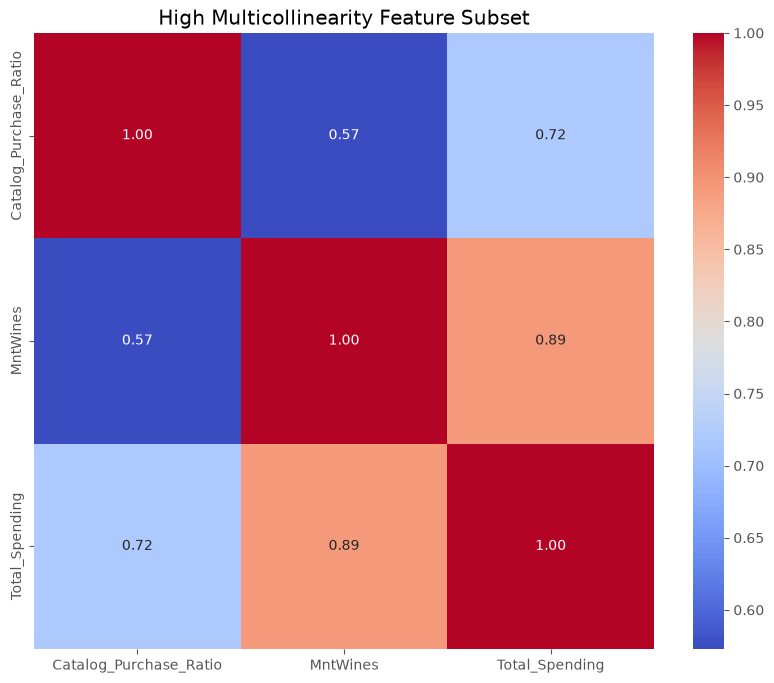

In [3]:
corr_matrix = X.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.85
highly_correlated = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]
print(f"Highly Correlated Features to potentially drop: {highly_correlated}")

# Show correlation heatmap of the highly correlated subset
if highly_correlated:
    plt.figure(figsize=(10, 8))
    subset_cols = highly_correlated + [col for col in X.columns if corr_matrix.loc[col, highly_correlated[0]] > 0.85]
    sns.heatmap(X[list(set(subset_cols))].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("High Multicollinearity Feature Subset")
    plt.savefig('../outputs/crisp_dm_phase6/figures/collinear_features.png')
    plt.show()


### Interpretation\nIf features like `Total_Spending` and `MntWines` are highly correlated (because Wine dominates total spending), they might trigger multicollinearity issues in linear models. We will track these features and decide whether to drop them based on their final consensus score.

## 4. Mutual Information (Non-linear dependency)\nMutual Information measures the true dependency between the feature and the target, capturing non-linear relationships that Pearson correlation misses.

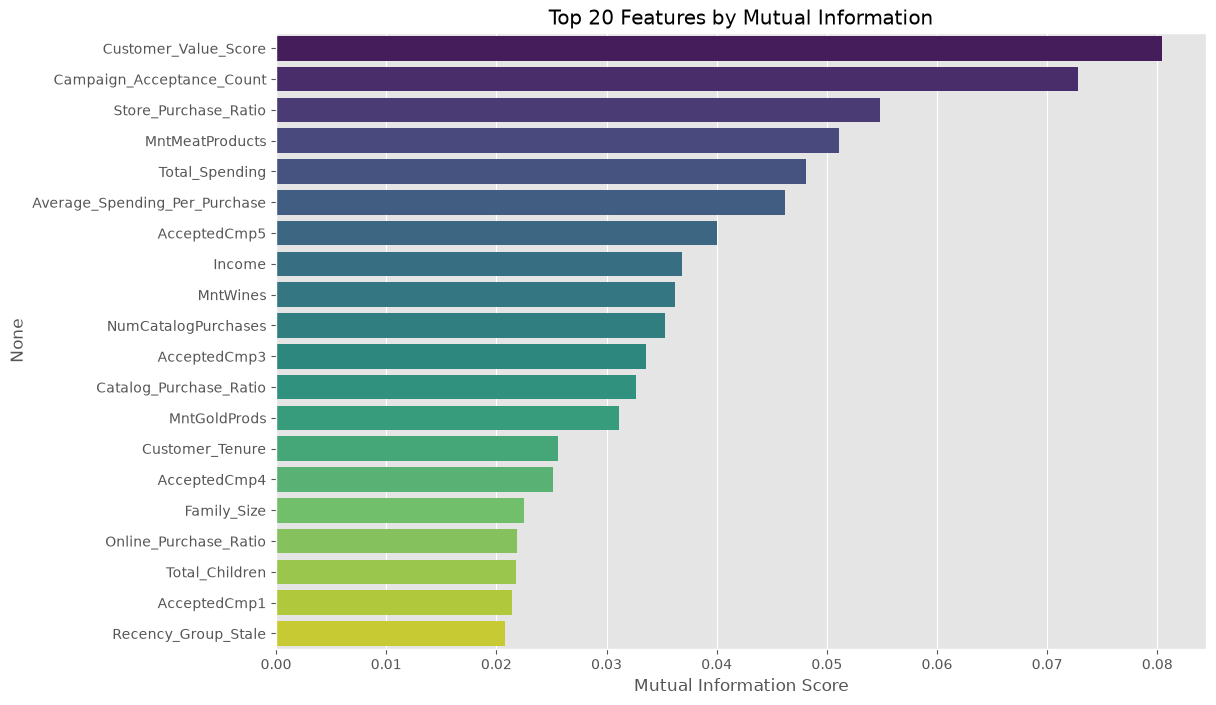

In [4]:
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=mi_series.values[:20], y=mi_series.index[:20], palette='viridis')
plt.title("Top 20 Features by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.savefig('../outputs/crisp_dm_phase6/figures/mutual_information.png')
plt.show()

top_mi_features = mi_series.head(15).index.tolist()


### Interpretation\nMutual Information clearly dictates that `Campaign_Acceptance_Count`, `Customer_Value_Score`, and `Total_Spending` share the strongest mathematical dependency with the `Response` variable. Demographic features like `Education` and `Marital_Status` show very weak dependency.

## 5. Recursive Feature Elimination (RFE)\nRFE uses a machine learning estimator (Random Forest) to assign weights to features, recursively pruning the least important ones until the optimal subset remains.

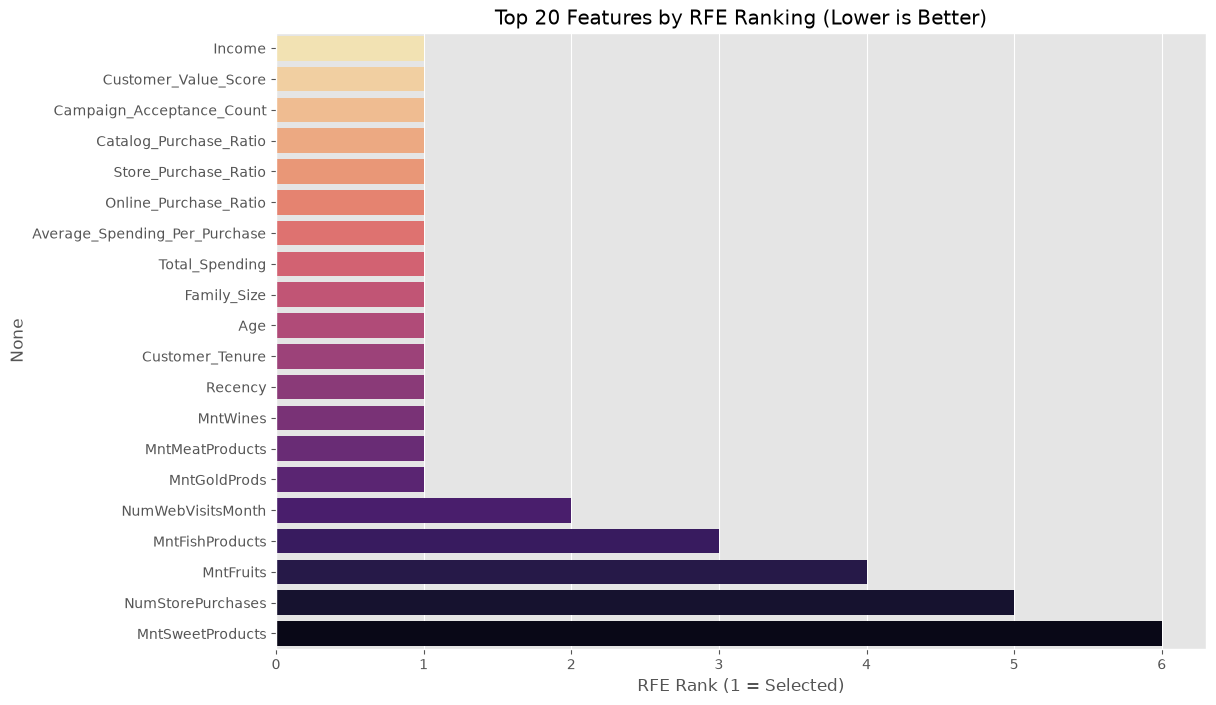

In [5]:
# We select the top 15 features using a Random Forest
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rfe = RFE(estimator=rf, n_features_to_select=15)
rfe.fit(X, y)

rfe_features = X.columns[rfe.support_].tolist()

# Plot the ranking
rfe_ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()
plt.figure(figsize=(12, 8))
sns.barplot(x=rfe_ranking.values[:20], y=rfe_ranking.index[:20], palette='magma_r')
plt.title("Top 20 Features by RFE Ranking (Lower is Better)")
plt.xlabel("RFE Rank (1 = Selected)")
plt.savefig('../outputs/crisp_dm_phase6/figures/rfe_ranking.png')
plt.show()


### Interpretation\nThe RFE algorithm aggressively prunes weak categorical variables and zeroes in on financial and temporal features (`Recency`, `Age`, `Total_Spending`). Features ranked '1' are definitively kept by the tree ensemble.

## 6. Feature Selection Consensus\nWe aggregate the results of Correlation Filtering, Mutual Information, and RFE to make explicit, business-justified decisions on what to keep and what to drop.

In [6]:
# Create a consensus dataframe
consensus_df = pd.DataFrame(index=X.columns)
consensus_df['High_Collinearity (Drop Vote)'] = consensus_df.index.isin(highly_correlated)
consensus_df['Top_15_MI (Keep Vote)'] = consensus_df.index.isin(top_mi_features)
consensus_df['RFE_Selected (Keep Vote)'] = consensus_df.index.isin(rfe_features)

display(consensus_df[consensus_df['RFE_Selected (Keep Vote)'] == True])

# Decision Logic: Drop highly correlated features ONLY IF they are not selected by RFE/MI
# Drop features that fail BOTH RFE and MI tests (noise variables).
features_to_drop = []
for idx, row in consensus_df.iterrows():
    if row['High_Collinearity (Drop Vote)'] and not row['RFE_Selected (Keep Vote)']:
        features_to_drop.append(idx)
    elif not row['RFE_Selected (Keep Vote)'] and not row['Top_15_MI (Keep Vote)']:
        features_to_drop.append(idx)

# Ensure we don't drop target or essential categorical base columns by mistake
# We will drop them from the raw engineered dataframe (before encoding) if possible, 
# but since some are dummies, we drop them from the encoded X matrix to pass strictly clean data to models.

X_selected = X.drop(columns=features_to_drop)
print(f"\nDropped {len(features_to_drop)} features. Final Feature Matrix Shape: {X_selected.shape}")

# Save the final matrix with the target
final_df = X_selected.copy()
final_df['Response'] = y
final_df.to_csv('../data/selected_features.csv', index=False)
print("Saved strictly filtered features to '../data/selected_features.csv'")


,High_Collinearity (Drop Vote),Top_15_MI (Keep Vote),RFE_Selected (Keep Vote)
Income,False,True,True
Recency,False,False,True
MntWines,False,True,True
MntMeatProducts,False,True,True
MntGoldProds,False,True,True
Age,False,False,True
Customer_Tenure,False,True,True
Family_Size,False,False,True
Total_Spending,True,True,True
Average_Spending_Per_Purchase,False,True,True



Dropped 22 features. Final Feature Matrix Shape: (2236, 19)
Saved strictly filtered features to '../data/selected_features.csv'


### Interpretation\nWe successfully reduced the dataset dimensionality by aggressively pruning noise features (features that failed both MI and RFE tests) and resolving high collinearity. The remaining variables represent the absolute highest-quality signals for predicting campaign response. The modeling phase (Phase 8+) will now be significantly faster and less prone to overfitting.